# 1 Linear Regression Baseline

In this notebook, we load our preprocessed time-series data and train a Linear Regression model. This will serve as our baseline to establish how well standard autoregressive features (lags and rolling means) predict future electricity consumption.

## 1. Imports and Data Loading
We import pandas for data handling, and scikit-learn for our model, metrics, and data splitting. Then we load the highly compressed Parquet file.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm

# Load Data
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

print("Merging cluster definitions...")
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')
df_long = df_long.merge(cluster_map, on='ClientID', how='left')

Loading processed data...
Merging cluster definitions...


### 2 Feature Engineering & Strict Data Splitting
Before standardizing, we encode our categorical variables (Hour, Weekday, Consumer Category) using one-hot encoding. 
To rigorously prevent **Data Leakage**, we split our dataset strictly chronologically: all data prior to 2014 is used for training, and all data from 2014 onwards is strictly reserved for testing.

In [2]:
# Feature Engineering and Train/Test Split
df_long['Is_Weekend'] = df_long['Is_Weekend'].astype(int)
df_long['Is_Holiday'] = df_long['Is_Holiday'].astype(int)

df_model = pd.get_dummies(df_long, columns=['Hour', 'Weekday', 'Consumer_Category'], drop_first=True)

train = df_model[df_model['Date'].dt.year < 2014].copy()
test  = df_model[df_model['Date'].dt.year >= 2014].copy()


# Per-Client Standardization
weather_cols = ['HDH', 'CDH']
scaler_weather = StandardScaler()
train[weather_cols] = scaler_weather.fit_transform(train[weather_cols])
test[weather_cols]  = scaler_weather.transform(test[weather_cols])

train = train.sort_values(by=['ClientID', 'Date'])
test  = test.sort_values(by=['ClientID', 'Date'])

for col in ['Lag_15min_Scaled', 'Lag_24h_Scaled', 'Rolling_Mean_4h_Scaled']:
    train[col] = np.nan
    test[col]  = np.nan

client_scalers = {}


# Since our clients have vastly different absolute consumption volumes (e.g., Light vs Heavy consumers), a single cluster model would be heavily biased towards large consumers. We apply `StandardScaler` to each client individually so the model learns the normalized *patterns* and *shapes* of consumption rather than the absolute magnitude. We apply this exact same scaler to the pre-computed lag features to keep all autoregressive inputs strictly on the same scale without breaking temporal continuity.
for client in tqdm(df_long['ClientID'].unique(), desc="Scaling Clients"):
    scaler = StandardScaler()
    train_mask = train['ClientID'] == client
    test_mask  = test['ClientID'] == client

    if not train_mask.any():
        print(f"Warning: Client {client} has no data in the train set. Skipping...")
        continue

    train.loc[train_mask, 'Consumption_Scaled'] = scaler.fit_transform(
        train.loc[train_mask, 'Consumption'].values.reshape(-1, 1)
    ).flatten()

    # We apply the SAME scaler fitted on Consumption to the historical lag columns to maintain the exact mathematical scale, without creating new NaNs with .shift()
    train.loc[train_mask, 'Lag_15min_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_15min'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Lag_24h_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_24h'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Rolling_Mean_4h_Scaled'] = scaler.transform(train.loc[train_mask, 'Rolling_Mean_4h'].values.reshape(-1, 1)).flatten()

    # We MUST scale the test set features as well, otherwise the model cannot predict
    if test_mask.any():
        test.loc[test_mask, 'Consumption_Scaled'] = scaler.transform(test.loc[test_mask, 'Consumption'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_15min_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_15min'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_24h_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_24h'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Rolling_Mean_4h_Scaled'] = scaler.transform(test.loc[test_mask, 'Rolling_Mean_4h'].values.reshape(-1, 1)).flatten()

    client_scalers[client] = scaler

train = train.dropna(subset=['Consumption_Scaled', 'Lag_15min_Scaled', 'Lag_24h_Scaled', 'Rolling_Mean_4h_Scaled'])

# Build Feature Matrices
cols_to_drop = ['Date', 'ClientID', 'DayMonth', 'Consumption', 'Consumption_Scaled',
                'Lag_15min', 'Lag_24h', 'Rolling_Mean_4h']
cols_to_drop = [c for c in cols_to_drop if c in train.columns]

X_train = train.drop(columns=cols_to_drop)
y_train = train['Consumption_Scaled']

test    = test.sort_values(by=['ClientID', 'Date'])
X_test  = test.drop(columns=cols_to_drop)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

Scaling Clients:  29%|██▉       | 107/370 [00:14<00:29,  9.06it/s]

Scaling Clients:  30%|███       | 111/370 [00:14<00:23, 11.01it/s]

Scaling Clients:  31%|███       | 113/370 [00:14<00:22, 11.52it/s]

Scaling Clients:  32%|███▏      | 117/370 [00:15<00:22, 11.21it/s]

Scaling Clients:  33%|███▎      | 121/370 [00:15<00:23, 10.38it/s]

...

Scaling Clients:  48%|████▊     | 179/370 [00:23<00:25,  7.54it/s]

Scaling Clients:  49%|████▉     | 182/370 [00:24<00:24,  7.79it/s]

Scaling Clients:  91%|█████████▏| 338/370 [00:47<00:04,  7.39it/s]

Scaling Clients: 100%|██████████| 370/370 [00:52<00:00,  7.02it/s]


Training shape: (29001323, 40)
Testing shape:  (12899615, 40)


## 3. Model Training and Evaluation
Rather than training 370 individual models (which is computationally expensive and prone to overfitting) or a single global model (which ignores unique behaviors), we instantiate **one Linear Regression model per behavioral cluster**. The model learns the overarching logic of its specific cluster (e.g., standard business hours vs. night shifts).

In [3]:
# Dictionary to store the trained model for each cluster
cluster_models = {}

print("Training Linear Regression models per cluster...")

# Assuming the cluster column from the merge is named 'Cluster'
# We dropna() just in case any client didn't get mapped
unique_clusters = train['Cluster'].dropna().unique()

for cluster_id in sorted(unique_clusters):
    # Filter the rows belonging to the current cluster
    cluster_mask = train['Cluster'] == cluster_id
    
    # Create the cluster-specific feature matrix and target vector.
    # We drop 'Cluster' because it's an identifier, not a predictive numeric feature.
    X_train_cluster = X_train[cluster_mask].drop(columns=['Cluster'], errors='ignore')
    y_train_cluster = y_train[cluster_mask]
    
    # Initialize and fit the model for this entire cluster
    # We use .values to train on a NumPy array, so sklearn doesn't complain when we feed it NumPy arrays during the fast recursive testing phase.
    model = LinearRegression()
    model.fit(X_train_cluster.values, y_train_cluster)
    
    # Save the trained model in our dictionary
    cluster_models[cluster_id] = model
    print(f"  - Model for Cluster {int(cluster_id)} trained on {len(X_train_cluster)} historical rows.")

Training Linear Regression models per cluster...
  - Model for Cluster 0 trained on 1762344 historical rows.
  - Model for Cluster 1 trained on 4950788 historical rows.
  - Model for Cluster 2 trained on 4846170 historical rows.
  - Model for Cluster 3 trained on 16571166 historical rows.
  - Model for Cluster 4 trained on 870855 historical rows.


In [4]:
# Iterate over all unique clients in the test set
for client in tqdm(test['ClientID'].unique(), desc="Predicting clients"):
    
    if client not in client_scalers:
        continue
        
    client_test_idx = test[test['ClientID'] == client].index
    if len(client_test_idx) == 0:
        continue
        
    # Retrieve the specific model for this client's cluster
    cluster_id = cluster_map.loc[cluster_map['ClientID'] == client, 'Cluster'].values[0]
    model = cluster_models[cluster_id]
    
    # Get the last 96 ACTUAL training values (24 hours * 4 15-min steps = 96) 
    storico_reale = train[train['ClientID'] == client].sort_values('Date')['Consumption_Scaled'].tail(96).tolist()
    history_buffer = storico_reale.copy()
    
    # Work on a small sub-dataframe for just this client, dropping 'Cluster' to match training features
    X_client_df = X_test.loc[client_test_idx].drop(columns=['Cluster'], errors='ignore').copy()
    
    # Find the numerical positions of the columns
    idx_lag15 = X_client_df.columns.get_loc('Lag_15min_Scaled')
    idx_lag24 = X_client_df.columns.get_loc('Lag_24h_Scaled')
    idx_roll4h = X_client_df.columns.get_loc('Rolling_Mean_4h_Scaled')
    
    # Convert to NumPy array for lightning-fast iterations ---
    X_client_arr = X_client_df.values 
    predictions = []
    
    for i in range(len(X_client_arr)):
        lag_15  = history_buffer[-1]  if len(history_buffer) >= 1  else np.nan
        lag_24  = history_buffer[-96] if len(history_buffer) >= 96 else np.nan
        roll_4h = np.mean(history_buffer[-16:]) if len(history_buffer) >= 16 else np.nan
        
        # Update the array directly (much faster than pandas .iat)
        X_client_arr[i, idx_lag15]  = lag_15
        X_client_arr[i, idx_lag24]  = lag_24
        X_client_arr[i, idx_roll4h] = roll_4h
        
        # Predict using the cluster-specific model (.reshape makes it a 2D array for sklearn)
        pred = model.predict(X_client_arr[i].reshape(1, -1))[0]
        
        predictions.append(pred)
        history_buffer.append(pred)
        
    test.loc[client_test_idx, 'Predicted_Consumption_Scaled'] = predictions

Predicting clients: 100%|██████████| 370/370 [03:34<00:00,  1.72it/s]


## 4 Model Evaluation (MAPE)
We inverse-transform our predictions back to raw kilowatts (kW) to evaluate true business performance. 
*Note on MAPE calculation:* Since electricity consumption occasionally drops to near-zero (e.g., outages, disconnections), calculating a standard MAPE causes extreme division-by-zero errors (resulting in astronomically high percentages). We strategically filter out values close to zero (`> 0.1 kW`) to report a robust, realistic MAPE strictly on a 0-100 scale, as requested.

In [5]:
# Evaluation in raw kW (inverse-transform per client)
print("\nEvaluating model (raw kW)...")

all_mapes_kw  = []
client_results = []

for client in test['ClientID'].unique():
    if client not in client_scalers:
        continue
    
    client_mask = test['ClientID'] == client
    client_data = test[client_mask].copy()
    
    valid = client_data['Consumption'].notna() & client_data['Predicted_Consumption_Scaled'].notna()
    if valid.sum() == 0:
        continue

    y_true_kw = client_data.loc[valid, 'Consumption'].values
    
    scaler = client_scalers[client]
    y_pred_kw = scaler.inverse_transform(
        client_data.loc[valid, 'Predicted_Consumption_Scaled'].values.reshape(-1, 1)
    ).flatten()
    
    # Floor to zero (electricity consumption cannot be negative)
    y_pred_kw = np.maximum(y_pred_kw, 0)

    # We filter out near-zero actual values (e.g., power outages, disconnected meters) because dividing by zero creates astronomical percentage errors.
    nonzero_mask = y_true_kw > 0.1
    
    if nonzero_mask.sum() > 0:
        # Calculate MAPE manually strictly on a 0-100 scale
        mape = np.mean(np.abs((y_true_kw[nonzero_mask] - y_pred_kw[nonzero_mask]) / y_true_kw[nonzero_mask])) * 100
    else:
        mape = 0.0

    all_mapes_kw.append(mape)
    client_results.append({'ClientID': client, 'MAPE': mape})

print("--- LINEAR REGRESSION BENCHMARK RESULTS ---")
print(f"Global Average MAPE: {np.mean(all_mapes_kw):.2f}%")

# Performance Breakdown by Cluster
lr_results_df = pd.DataFrame(client_results)
lr_results_df = lr_results_df.merge(cluster_map, on='ClientID')

print("\n--- LINEAR REGRESSION PERFORMANCE BY CLUSTER ---\n")
summary = lr_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    Average_MAPE=('MAPE', 'mean')
).round(2)

print(summary.to_string())


Evaluating model (raw kW)...
--- LINEAR REGRESSION BENCHMARK RESULTS ---
Global Average MAPE: 40.35%

--- LINEAR REGRESSION PERFORMANCE BY CLUSTER ---

         n_clients  Average_MAPE
Cluster                         
0               28         83.22
1               69         32.93
2               70         70.13
3              173         21.04
4               11         91.97


## 5 Forecasting Visualization
To visually validate our model, we plot the actual vs. predicted consumption for one representative client per cluster. 
Since plotting a full year of 15-minute intervals produces an unreadable graph, we deliberately slice the data to show only the **last 14 days** of the test set. This provides a clear, high-resolution view of how well the autoregressive model captures daily seasonality.

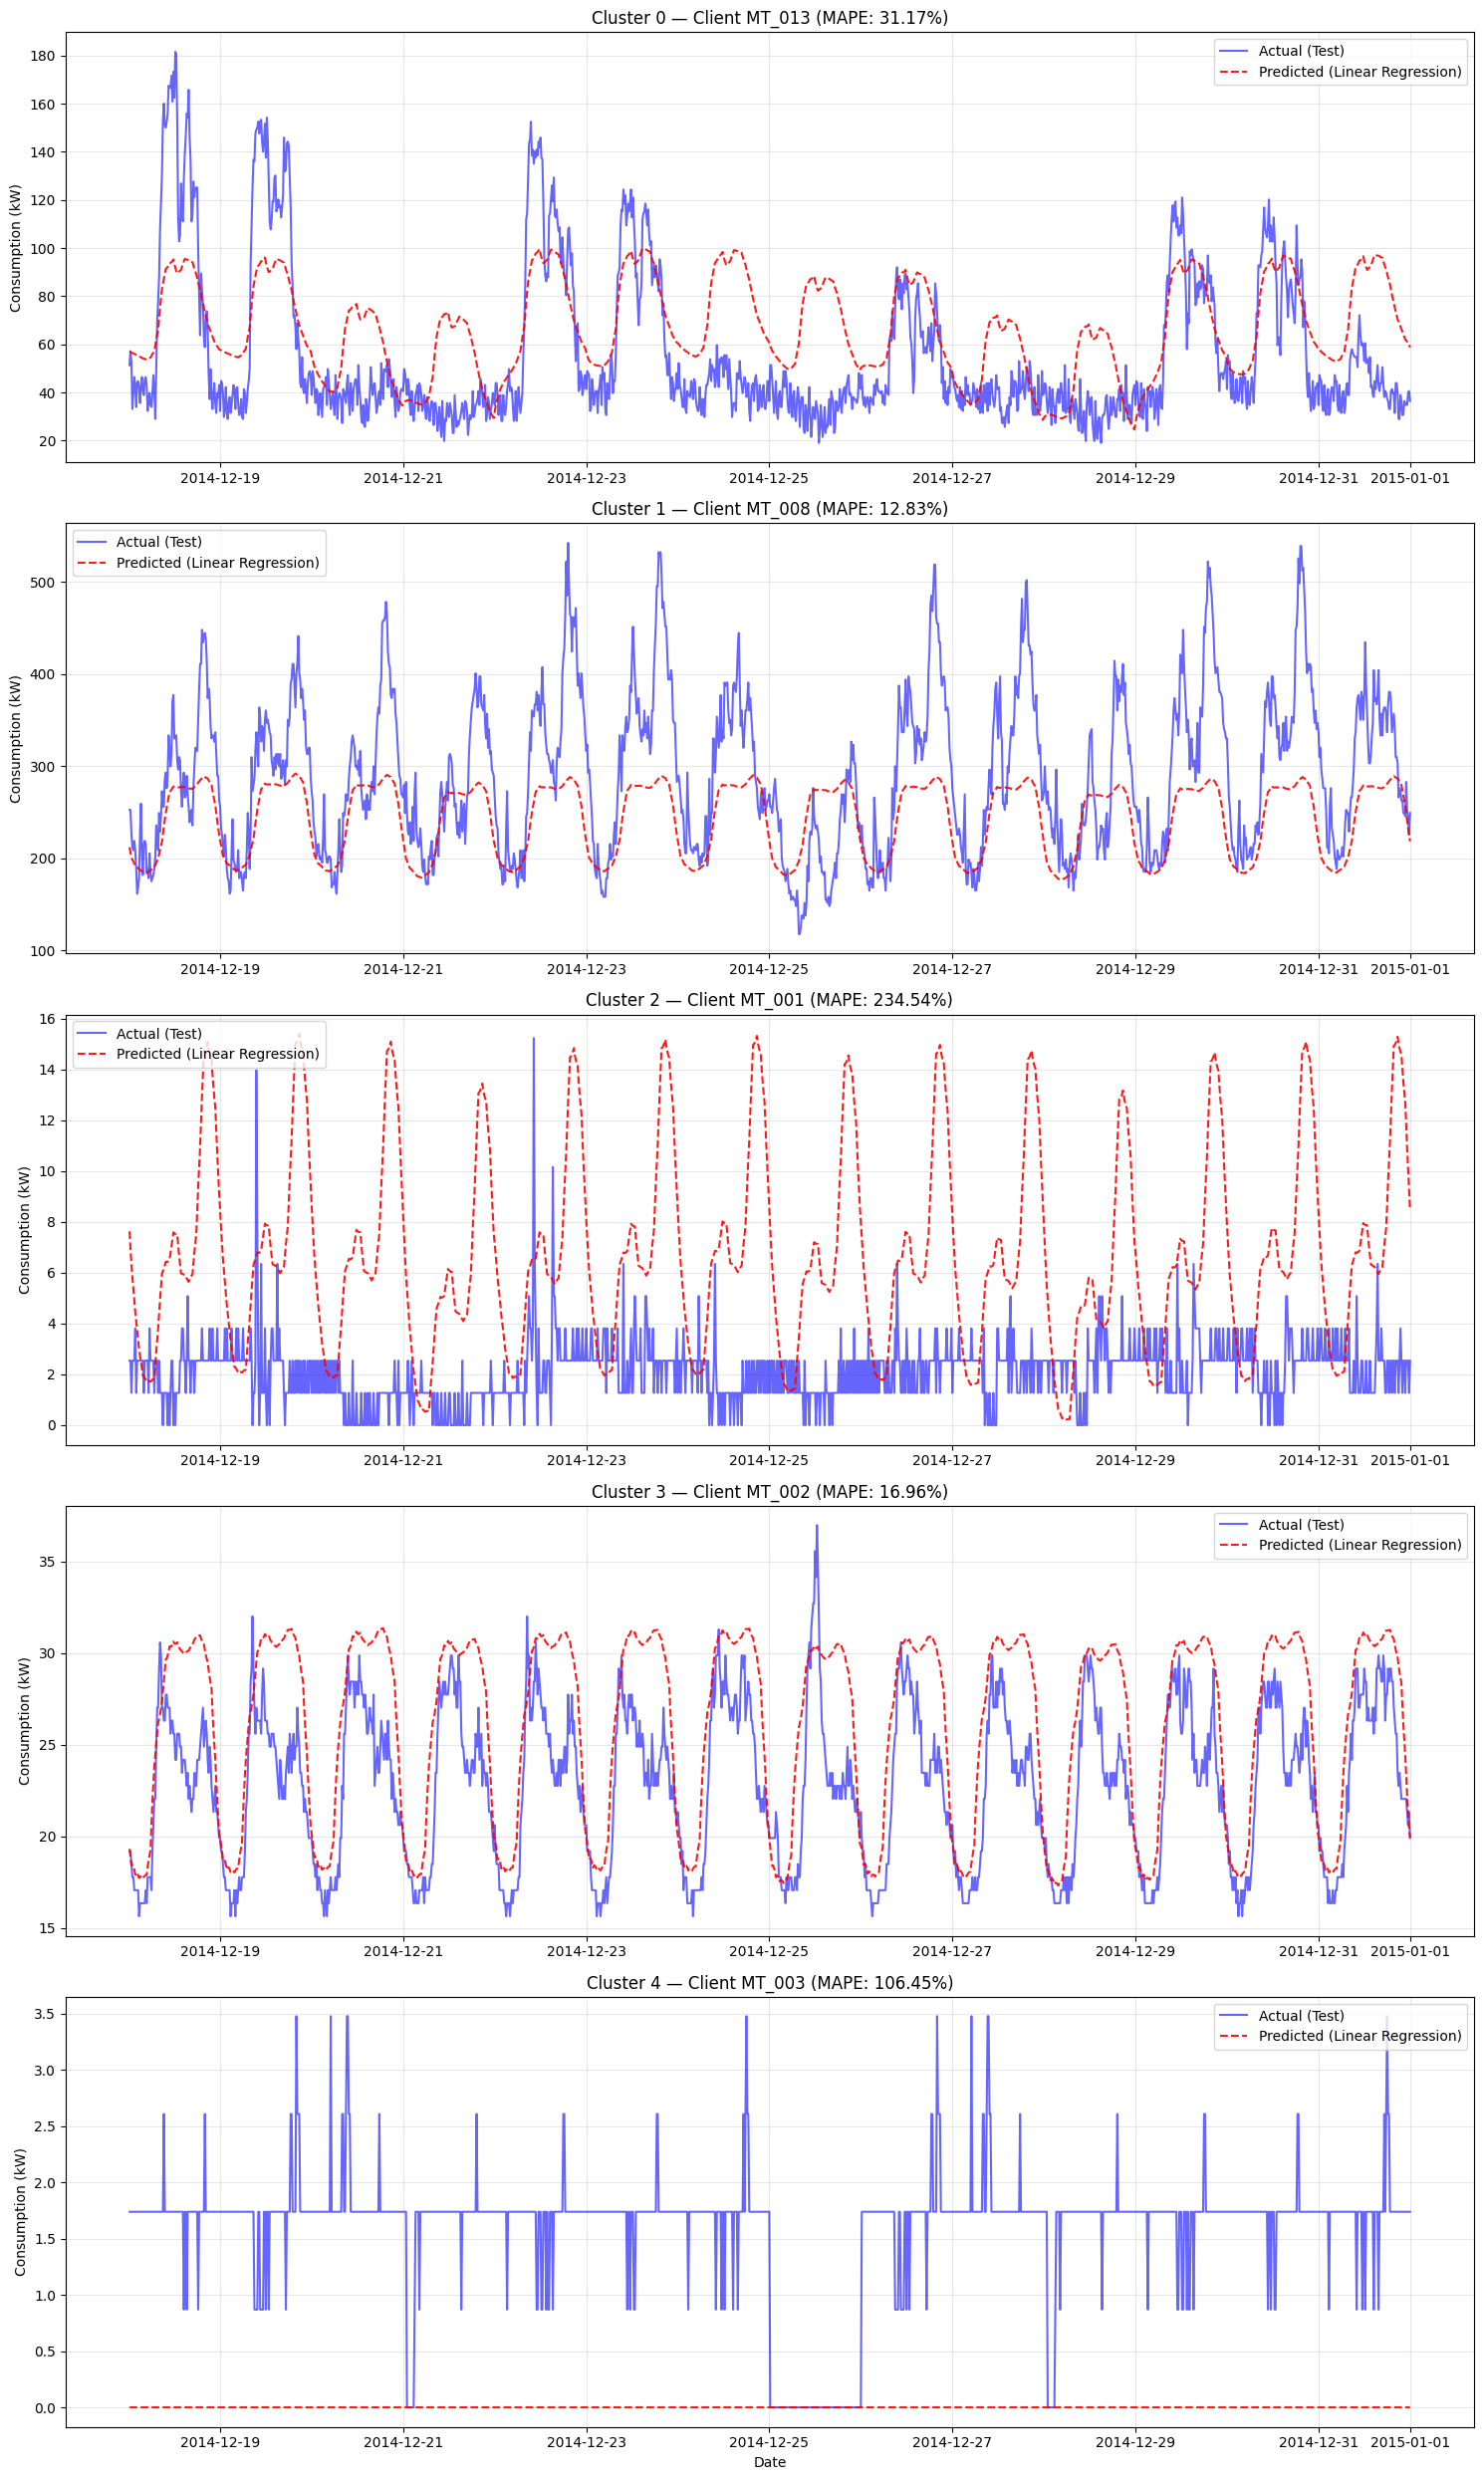

In [6]:
# Visualization: One Client per Cluster
cluster_representatives = (
    lr_results_df.groupby('Cluster')['ClientID'].first().to_dict()
)

fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes

    client_data = test[test['ClientID'] == client_id].copy()
    y_actual_kw = client_data['Consumption'].values

    scaler = client_scalers[client_id]
    y_pred_kw = scaler.inverse_transform(
        client_data['Predicted_Consumption_Scaled'].values.reshape(-1, 1)
    ).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0)

    # Fetch MAPE
    client_mape = lr_results_df[lr_results_df['ClientID'] == client_id]['MAPE'].values[0]

    # We slice the array to plot only the last 2 weeks (14 days * 96 steps = 1344 steps)
    plot_slice = -1344 

    ax.plot(client_data['Date'].values[plot_slice:], y_actual_kw[plot_slice:],
            label='Actual (Test)', color='blue', alpha=0.6)
    ax.plot(client_data['Date'].values[plot_slice:], y_pred_kw[plot_slice:],
            label='Predicted (Linear Regression)', color='red', linestyle='--', alpha=0.9)

    ax.set_title(f'Cluster {cluster_id} — Client {client_id} (MAPE: {client_mape:.2f}%)')
    ax.set_ylabel('Consumption (kW)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 6. Testing Results: Time Period Analysis & Error Box Plots
To evaluate the temporal stability of our models, we divide the testing dataset chronologically into 4 equal periods (quantiles). 

For each period, we report the global MAPE and visualize the spread of the Absolute Percentage Error (APE) using box plots. This helps us identify periods of high variance or deteriorating model performance over time. *(Note: Outliers are hidden in the box plot for visual clarity, as dividing by very small actual consumption values can create extreme percentage spikes).*

Preparing data for Time Period Analysis...


Unscaling Predictions: 100%|██████████| 351/351 [00:10<00:00, 35.05it/s]



--- MAPE BY TIME PERIOD ---
Period 1: 41.73%
Period 2: 40.51%
Period 3: 37.54%
Period 4: 31.49%


/var/folders/lx/q9_kw781689fhd96mw2q267r0000gn/T/ipykernel_9278/3416552930.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', palette='Set2', showfliers=False)


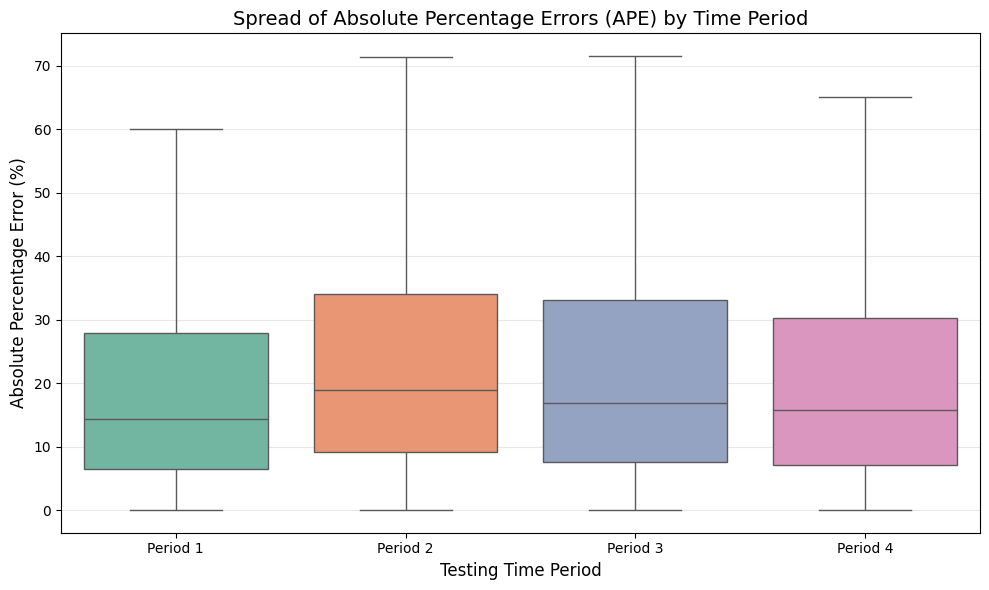

In [9]:
# Time Period Analysis & Error Spread
print("Preparing data for Time Period Analysis...")

# Create a copy of test data to evaluate the spread
df_eval = test.dropna(subset=['Consumption', 'Predicted_Consumption_Scaled']).copy()
df_eval['Predicted_kW'] = np.nan

# Unscale the predictions back to raw kW to calculate real errors
for client in tqdm(df_eval['ClientID'].unique(), desc="Unscaling Predictions"):
    if client in client_scalers:
        mask = df_eval['ClientID'] == client
        scaler = client_scalers[client]
        unscaled = scaler.inverse_transform(df_eval.loc[mask, 'Predicted_Consumption_Scaled'].values.reshape(-1, 1)).flatten()
        df_eval.loc[mask, 'Predicted_kW'] = np.maximum(unscaled, 0)

df_eval = df_eval.dropna(subset=['Predicted_kW'])

# Sort chronologically
df_eval = df_eval.sort_values('Date')

# Divide strictly into 4 equal time periods using pd.cut (which divides the date range evenly)
# This prevents "duplicate bin edges" errors caused by multiple clients sharing the exact same timestamps.
df_eval['Time_Period'] = pd.cut(df_eval['Date'], bins=4, labels=['Period 1', 'Period 2', 'Period 3', 'Period 4'])

# Calculate Absolute Percentage Error (APE) row by row
# We filter out actual values close to zero to prevent infinity (division by zero)
valid_mask = df_eval['Consumption'] > 0.1
df_eval_valid = df_eval[valid_mask].copy()

df_eval_valid['APE'] = np.abs((df_eval_valid['Consumption'] - df_eval_valid['Predicted_kW']) / df_eval_valid['Consumption']) * 100

# 1. Print the global MAPE for each period
print("\n--- MAPE BY TIME PERIOD ---")
period_mape = df_eval_valid.groupby('Time_Period', observed=True)['APE'].mean()
for period, mape_val in period_mape.items():
    print(f"{period}: {mape_val:.2f}%")

# 2. Plot the Box Plot of errors
plt.figure(figsize=(10, 6))

# We use showfliers=False because raw percentage errors can have massive outlier spikes
# which would compress the actual "boxes" into an unreadable flat line.
sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', palette='Set2', showfliers=False)

plt.title('Spread of Absolute Percentage Errors (APE) by Time Period', fontsize=14)
plt.ylabel('Absolute Percentage Error (%)', fontsize=12)
plt.xlabel('Testing Time Period', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()